In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import init_creds as creds
import sys
from langchain_openai import AzureChatOpenAI

sys.path.insert(1, '../../')

# # Configure Azure OpenAI And OpenAI Embeddings
# AZURE_OPENAI_KEY = os.getenv('OPENAI_API_KEY')
# AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
# AZURE_OPENAI_API_VERSION = os.getenv('OPENAI_API_VERSION')


AZURE_OPENAI_KEY = creds.get_api_key()
AZURE_OPENAI_ENDPOINT = creds.get_endpoint()
AZURE_OPENAI_API_VERSION = "2025-04-01-preview"

if not AZURE_OPENAI_KEY:
    raise ValueError("No AZURE_OPENAI_KEY set for Azure OpenAI API")
if not AZURE_OPENAI_ENDPOINT:
    raise ValueError("No AZURE_OPENAI_ENDPOINT set for Azure OpenAI API")

llm = AzureChatOpenAI(
    model="gpt-4o-mini",
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_KEY,
    api_version=AZURE_OPENAI_API_VERSION
)


In [2]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [3]:
# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

In [4]:
# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

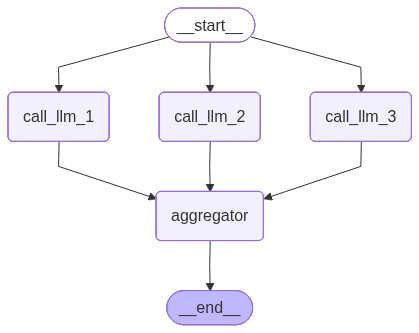

In [5]:
# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))



In [6]:
# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
In the quaint little village of Whiskerton, nestled between lush rolling hills and a sparkling stream, there existed a peculiar legend about a secret council of cats. These were no ordinary felines; they were the keepers of wisdom and protectors of the secrets of the village.

Every evening, as the sun dipped below the horizon, casting a golden hue over the rooftops, the cats of Whiskerton would gather at the old oak tree in the town square. The tree, ancient and gnarled, with branches that stretched toward the sky like welcoming arms, was the perfect meeting spot. The villagers, too preoccupied with their daily lives, thought nothing of the gathering and believed it nothing more than a nightly ritual of their beloved pets.

Among these cats was a clever tabby named Whiskers. With fur that twinkled like stardust in the moonlight and eyes like two luminous emeralds, Whiskers was not just any cat; he was the unofficial leader of the coun